In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("car_data.csv")

In [3]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [5]:
df.shape

(11914, 16)

In [6]:
df.isna().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [7]:
for col in df.columns:
    print(col, "sütunu farklı değer sayısı:", df[col].nunique())


Make sütunu farklı değer sayısı: 48
Model sütunu farklı değer sayısı: 915
Year sütunu farklı değer sayısı: 28
Engine Fuel Type sütunu farklı değer sayısı: 10
Engine HP sütunu farklı değer sayısı: 356
Engine Cylinders sütunu farklı değer sayısı: 9
Transmission Type sütunu farklı değer sayısı: 5
Driven_Wheels sütunu farklı değer sayısı: 4
Number of Doors sütunu farklı değer sayısı: 3
Market Category sütunu farklı değer sayısı: 71
Vehicle Size sütunu farklı değer sayısı: 3
Vehicle Style sütunu farklı değer sayısı: 16
highway MPG sütunu farklı değer sayısı: 59
city mpg sütunu farklı değer sayısı: 69
Popularity sütunu farklı değer sayısı: 48
MSRP sütunu farklı değer sayısı: 6049


In [8]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [9]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

In [10]:
df[numeric_cols].isna().sum()

Year                 0
Engine HP           69
Engine Cylinders    30
Number of Doors      6
highway MPG          0
city mpg             0
Popularity           0
MSRP                 0
dtype: int64

In [11]:
df = df.dropna(subset=numeric_cols)

In [12]:
df[numeric_cols].isna().sum()

Year                0
Engine HP           0
Engine Cylinders    0
Number of Doors     0
highway MPG         0
city mpg            0
Popularity          0
MSRP                0
dtype: int64

In [13]:
df[categorical_cols].isna().sum()

Make                    0
Model                   0
Engine Fuel Type        3
Transmission Type       0
Driven_Wheels           0
Market Category      3731
Vehicle Size            0
Vehicle Style           0
dtype: int64

In [14]:
df = df.dropna(subset = ["Engine Fuel Type"])

In [15]:
df.isna().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        0
Engine HP               0
Engine Cylinders        0
Transmission Type       0
Driven_Wheels           0
Number of Doors         0
Market Category      3728
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [16]:
df = df.drop("Market Category", axis = 1)

In [17]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


In [18]:
df[df["Engine Cylinders"]==0]

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
1680,Mercedes-Benz,B-Class Electric Drive,2015,electric,177.0,0.0,DIRECT_DRIVE,front wheel drive,4.0,Compact,4dr Hatchback,82,85,617,41450
1681,Mercedes-Benz,B-Class Electric Drive,2016,electric,177.0,0.0,DIRECT_DRIVE,front wheel drive,4.0,Compact,4dr Hatchback,82,85,617,41450
1682,Mercedes-Benz,B-Class Electric Drive,2017,electric,177.0,0.0,DIRECT_DRIVE,front wheel drive,4.0,Compact,4dr Hatchback,82,85,617,39900
5790,BMW,i3,2015,electric,170.0,0.0,DIRECT_DRIVE,rear wheel drive,4.0,Compact,4dr Hatchback,111,137,3916,42400
5791,BMW,i3,2016,electric,170.0,0.0,DIRECT_DRIVE,rear wheel drive,4.0,Compact,4dr Hatchback,111,137,3916,42400
5792,BMW,i3,2017,electric,170.0,0.0,DIRECT_DRIVE,rear wheel drive,4.0,Compact,4dr Hatchback,111,137,3916,42400
5793,BMW,i3,2017,electric,170.0,0.0,DIRECT_DRIVE,rear wheel drive,4.0,Compact,4dr Hatchback,106,129,3916,43600
9867,Chevrolet,Spark EV,2014,electric,140.0,0.0,DIRECT_DRIVE,front wheel drive,4.0,Compact,4dr Hatchback,109,128,1385,26685
9868,Chevrolet,Spark EV,2014,electric,140.0,0.0,DIRECT_DRIVE,front wheel drive,4.0,Compact,4dr Hatchback,109,128,1385,27010
9869,Chevrolet,Spark EV,2015,electric,140.0,0.0,DIRECT_DRIVE,front wheel drive,4.0,Compact,4dr Hatchback,109,128,1385,25170


In [19]:
(df["Engine Cylinders"]==0).sum()

np.int64(13)

In [20]:
# 0 silindirli olduğu söylenen 13 veri temizlenecek.

In [21]:
df.drop(df[df["Engine Cylinders"]==0].index, inplace=True)

In [22]:
(df["Engine Cylinders"]==0).sum()

np.int64(0)

In [23]:
for col in df.select_dtypes(include=['object', 'category']).columns.tolist():
    print(col, "sütunu farklı değer sayısı:", df[col].nunique())

Make sütunu farklı değer sayısı: 47
Model sütunu farklı değer sayısı: 901
Engine Fuel Type sütunu farklı değer sayısı: 8
Transmission Type sütunu farklı değer sayısı: 5
Driven_Wheels sütunu farklı değer sayısı: 4
Vehicle Size sütunu farklı değer sayısı: 3
Vehicle Style sütunu farklı değer sayısı: 16


In [24]:
df["Model"].value_counts()

Model
Silverado 1500        156
Tundra                140
F-150                 126
Sierra 1500            90
Beetle Convertible     89
                     ... 
Blackwood               1
V90                     1
XC                      1
1 Series M              1
Zephyr                  1
Name: count, Length: 901, dtype: int64

<Axes: >

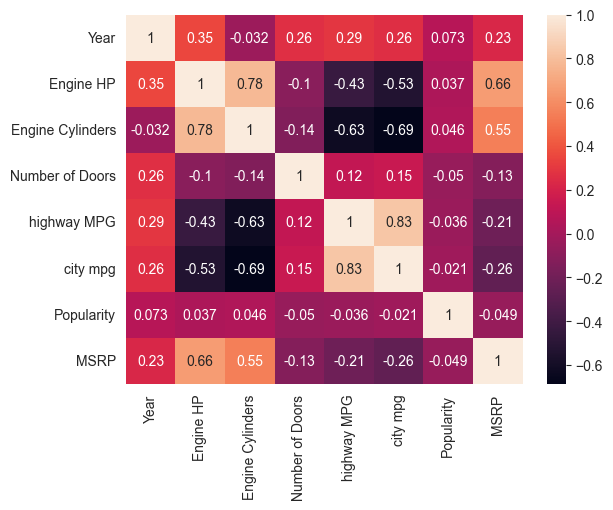

In [25]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [26]:
df.drop("Popularity", axis=1, inplace=True)

In [27]:
df["Vehicle Style"].value_counts()

Vehicle Style
Sedan                  3013
4dr SUV                2480
Coupe                  1190
Convertible             793
Crew Cab Pickup         681
4dr Hatchback           665
Extended Cab Pickup     623
Wagon                   587
2dr Hatchback           503
Passenger Minivan       412
Regular Cab Pickup      392
2dr SUV                 138
Passenger Van           128
Cargo Van                95
Cargo Minivan            70
Convertible SUV          29
Name: count, dtype: int64

In [28]:
df = df.drop("Model",axis=1)

In [29]:
for col in df.select_dtypes(include=['object', 'category']).columns.tolist():
    print(col, "sütunu farklı değer sayısı:", df[col].nunique())

Make sütunu farklı değer sayısı: 47
Engine Fuel Type sütunu farklı değer sayısı: 8
Transmission Type sütunu farklı değer sayısı: 5
Driven_Wheels sütunu farklı değer sayısı: 4
Vehicle Size sütunu farklı değer sayısı: 3
Vehicle Style sütunu farklı değer sayısı: 16


In [30]:
X = df.drop("MSRP",axis=1)
y = df["MSRP"]

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

In [32]:
one_hot_categories = [
'Engine Fuel Type',
'Transmission Type',
'Driven_Wheels',
'Vehicle Size',
]

target_category = ['Make','Vehicle Style']

In [33]:
from sklearn.preprocessing import OneHotEncoder,TargetEncoder
from sklearn.compose import ColumnTransformer

encoder = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), one_hot_categories),
        ("target", TargetEncoder(), target_category)
    ],
    remainder="passthrough"
)


In [34]:
X_train_enc = encoder.fit_transform(X_train,y_train)
X_test_enc = encoder.transform(X_test)

C:\Users\cemal\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_target_encoder.py:363: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  inferred_type_of_target = type_of_target(y, input_name="y")
C:\Users\cemal\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_label.py:302: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  self.y_type_ = type_of_target(y, input_name="y")
C:\Users\cemal\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\Users\cemal\AppData\Lo

In [35]:
X_train_enc

array([[ 0.,  0.,  0., ...,  3., 19., 14.],
       [ 0.,  0.,  0., ...,  4., 31., 21.],
       [ 0.,  0.,  0., ...,  2., 34., 28.],
       ...,
       [ 0.,  0.,  0., ...,  4., 17., 13.],
       [ 0.,  0.,  0., ...,  4., 30., 23.],
       [ 0.,  0.,  0., ...,  4., 50., 54.]])

In [36]:
columns = encoder.get_feature_names_out()

In [37]:
X_train = pd.DataFrame(X_train_enc, columns=columns, index=X_train.index)
X_test = pd.DataFrame(X_test_enc, columns=columns, index=X_test.index)

In [38]:
columns

array(['onehot__Engine Fuel Type_diesel',
       'onehot__Engine Fuel Type_flex-fuel (premium unleaded recommended/E85)',
       'onehot__Engine Fuel Type_flex-fuel (premium unleaded required/E85)',
       ..., 'remainder__Number of Doors', 'remainder__highway MPG',
       'remainder__city mpg'], dtype=object)

In [39]:
X_train

,onehot__Engine Fuel Type_diesel,onehot__Engine Fuel Type_flex-fuel (premium unleaded recommended/E85),onehot__Engine Fuel Type_flex-fuel (premium unleaded required/E85),onehot__Engine Fuel Type_flex-fuel (unleaded/E85),onehot__Engine Fuel Type_natural gas,onehot__Engine Fuel Type_premium unleaded (recommended),onehot__Engine Fuel Type_premium unleaded (required),onehot__Engine Fuel Type_regular unleaded,onehot__Transmission Type_AUTOMATED_MANUAL,onehot__Transmission Type_AUTOMATIC,...,target__Vehicle Style_643330,target__Vehicle Style_1380000,target__Vehicle Style_1705769,target__Vehicle Style_2065902,remainder__Year,remainder__Engine HP,remainder__Engine Cylinders,remainder__Number of Doors,remainder__highway MPG,remainder__city mpg
10727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.000000,0.00000,0.00000,2017.0,275.0,6.0,3.0,19.0,14.0
6911,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.000000,0.00000,0.00000,2017.0,245.0,4.0,4.0,31.0,21.0
561,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.00000,0.00000,2016.0,135.0,4.0,2.0,34.0,28.0
10945,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.000000,0.00000,0.00000,2015.0,381.0,8.0,4.0,17.0,13.0
634,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.000000,0.00000,0.00000,2015.0,445.0,8.0,4.0,24.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6584,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.001998,0.00000,0.00000,1991.0,162.0,6.0,2.0,23.0,17.0
2701,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.000000,0.00138,0.00138,2003.0,260.0,6.0,2.0,27.0,17.0
8154,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.000000,0.00000,0.00000,2008.0,310.0,8.0,4.0,17.0,13.0
3845,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.000000,0.00000,0.00000,2010.0,138.0,4.0,4.0,30.0,23.0


In [40]:
df["Vehicle Style"].value_counts()

Vehicle Style
Sedan                  3013
4dr SUV                2480
Coupe                  1190
Convertible             793
Crew Cab Pickup         681
4dr Hatchback           665
Extended Cab Pickup     623
Wagon                   587
2dr Hatchback           503
Passenger Minivan       412
Regular Cab Pickup      392
2dr SUV                 138
Passenger Van           128
Cargo Van                95
Cargo Minivan            70
Convertible SUV          29
Name: count, dtype: int64

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

In [42]:
from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [43]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

y_pred = model.predict(X_test_scaled)
print("r2 score:", r2_score(y_test,y_pred))
print("mean absolute error:", mean_absolute_error(y_test,y_pred))
print("mean squared error:", mean_squared_error(y_test,y_pred))

r2 score: 0.8757566809654236
mean absolute error: 4745.63232421875
mean squared error: 567752832.0


In [51]:
encoder

,transformers,"[('onehot', ...), ('target', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,False


In [52]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [53]:
model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [59]:
import pickle

with open("car_price_model.pkl", "wb") as f:
    pickle.dump(
        {
            "scaler": scaler,
            "model": model,
            "encoders": encoder
        }
    ,f)

In [55]:
df.head()

,Make,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,MSRP
0,BMW,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,46135
1,BMW,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,40650
2,BMW,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,36350
3,BMW,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,29450
4,BMW,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,34500


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11799 entries, 0 to 11913
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11799 non-null  object 
 1   Year               11799 non-null  int64  
 2   Engine Fuel Type   11799 non-null  object 
 3   Engine HP          11799 non-null  float64
 4   Engine Cylinders   11799 non-null  float64
 5   Transmission Type  11799 non-null  object 
 6   Driven_Wheels      11799 non-null  object 
 7   Number of Doors    11799 non-null  float64
 8   Vehicle Size       11799 non-null  object 
 9   Vehicle Style      11799 non-null  object 
 10  highway MPG        11799 non-null  int64  
 11  city mpg           11799 non-null  int64  
 12  MSRP               11799 non-null  int64  
dtypes: float64(3), int64(4), object(6)
memory usage: 1.3+ MB


In [61]:
df[df.select_dtypes(include=['object', 'category']).columns.tolist()].value_counts()

Make        Engine Fuel Type                Transmission Type  Driven_Wheels      Vehicle Size  Vehicle Style
Honda       regular unleaded                AUTOMATIC          front wheel drive  Midsize       Sedan            61
Volkswagen  regular unleaded                AUTOMATIC          front wheel drive  Midsize       Sedan            55
Hyundai     regular unleaded                AUTOMATIC          front wheel drive  Midsize       Sedan            54
Toyota      regular unleaded                AUTOMATIC          front wheel drive  Midsize       Sedan            52
Volkswagen  premium unleaded (recommended)  AUTOMATED_MANUAL   front wheel drive  Midsize       Sedan            51
                                                                                                                 ..
Acura       premium unleaded (required)     MANUAL             front wheel drive  Compact       Sedan             1
                                                               all wheel drive